In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

In [ ]:
data=load_wine()
X=data.data
y=data.target
df=pd.DataFrame(X,columns=data.feature_names)
df['target']=y
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [ ]:
data.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline']

In [ ]:
df.shape

(178, 14)

In [ ]:
print(data.target[:])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]


In [ ]:
print(data.data)
print(data.target)
print(data.target_names)
print(data.feature_names)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
['class_0' 'class_1' 'class_2']
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines',

In [ ]:
print(data.target_names)

['class_0' 'class_1' 'class_2']


In [ ]:
X=df.drop('target',axis=1)
y=df['target']

In [ ]:
print("\nTarget class distribution:\n",df['target'].value_counts())


Target class distribution:
 target
1    71
0    59
2    48
Name: count, dtype: int64


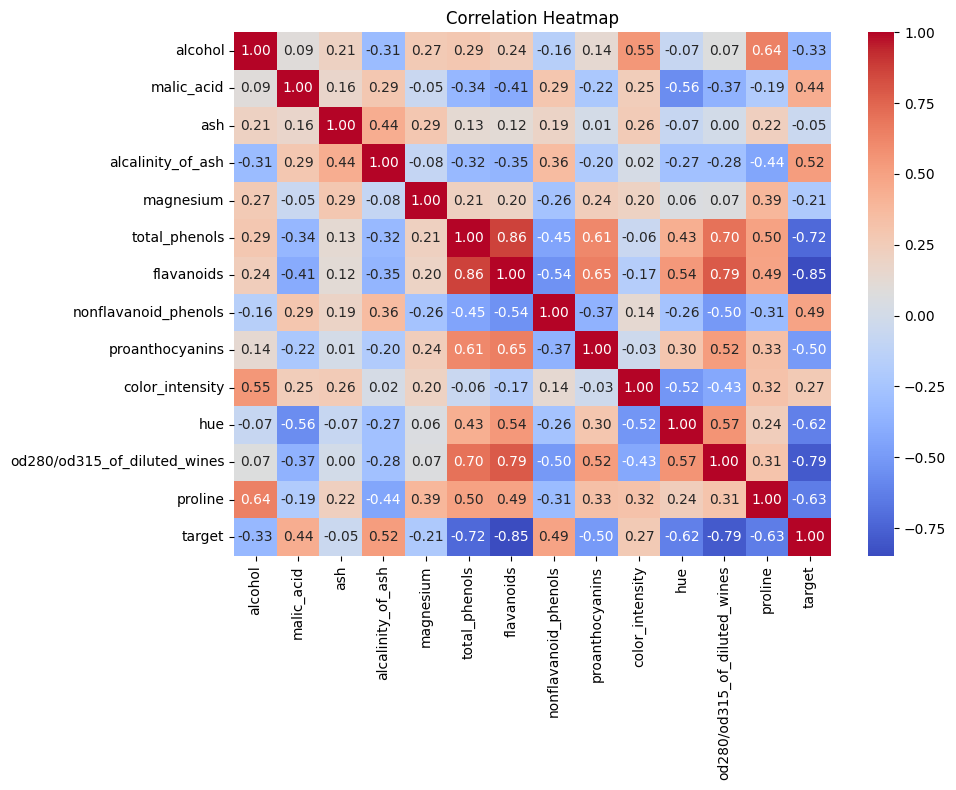

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True,fmt=".2f",cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
X_scaled.shape

(178, 13)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [ ]:
print("training data shape:",x_train.shape)
print("testingdata shape:",x_test.shape)



training data shape: (142, 13)
testingdata shape: (36, 13)


# Implementing KNN without library functions

In [ ]:
class KNN :
  def __init__(self,k=3) :
    self.k=k

  # store training data
  def fit(self,X,y):
    self.X_train=X
    self.y_train=y

  # Euclidean distances
  def euclidean_distances(self,x1,x2):
    return np.sqrt(np.sum((x1-x2)**2))

  # Predict one sample
  def predict_single(self,x):
    distances=[]
    for train_sample in self.X_train:
      distance=self.euclidean_distances(x,train_sample)
      distances.append(distance)

    k_indices=np.argsort(distances)[:self.k]
    k_labels=[self.y_train.iloc[i] for i in k_indices]
    prediction=Counter(k_labels).most_common(1)[0][0]
    return prediction

  def predict(self,X_test):
    predictions=[]

    for  sample in X_test:
      prediction=self.predict_single(sample)
      predictions.append(prediction)

    return np.array(predictions)

In [ ]:
new_sample=np.array([[13.5,1.8,2.4,16.5,105,2.8,2.9,0.3,1.9,5.2,1.05,3.2,950]])

In [ ]:

new_sample_scaled=scaler.transform(new_sample)
knn=KNN(k=3)
knn.fit(x_train, y_train)
prediction=knn.predict(new_sample_scaled,)

print("predicted class",prediction[0])
print("wine category",data.target_names[prediction[0]])


predicted class 0
wine category class_0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
y_pred = knn.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of KNN model: {accuracy:.4f}")

Accuracy of KNN model: 0.9444


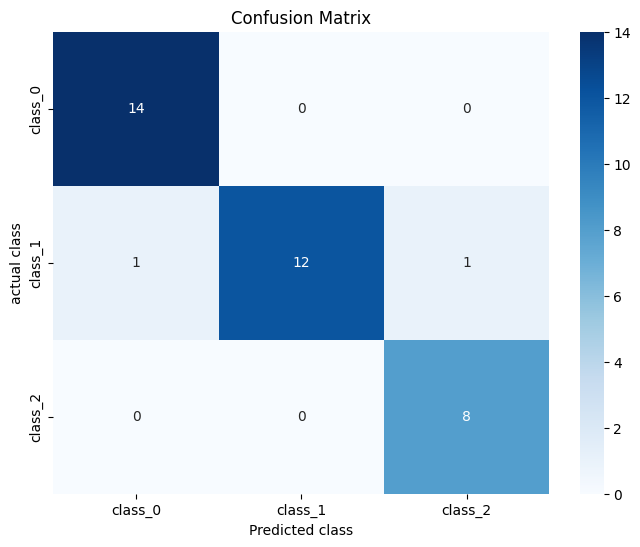

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

### Experimenting with different `k` values



In [ ]:
# List to store accuracies for different k values
accuracies = []
k_values = range(1, 21)

for k in k_values:
    knn_model = KNN(k=k)
    knn_model.fit(x_train, y_train)
    y_pred_k = knn_model.predict(x_test)
    acc = accuracy_score(y_test, y_pred_k)
    accuracies.append(acc)
    print(f"k = {k}, Accuracy = {acc:.4f}")



k = 1, Accuracy = 0.9444
k = 2, Accuracy = 0.9444
k = 3, Accuracy = 0.9444
k = 4, Accuracy = 0.9444
k = 5, Accuracy = 0.9444
k = 6, Accuracy = 0.9444
k = 7, Accuracy = 0.9444
k = 8, Accuracy = 0.9444
k = 9, Accuracy = 0.9444
k = 10, Accuracy = 0.9444
k = 11, Accuracy = 0.9444
k = 12, Accuracy = 0.9444
k = 13, Accuracy = 0.9444
k = 14, Accuracy = 0.9444
k = 15, Accuracy = 0.9722
k = 16, Accuracy = 0.9722
k = 17, Accuracy = 0.9722
k = 18, Accuracy = 0.9444
k = 19, Accuracy = 0.9444
k = 20, Accuracy = 0.9444


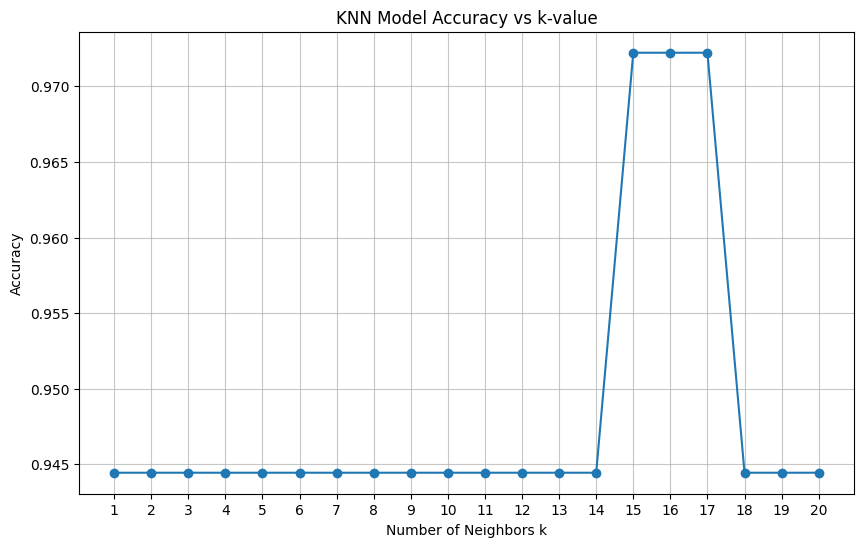

In [ ]:
# Plotting the results
fig = plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-')
plt.title('KNN Model Accuracy vs k-value')
plt.xlabel('Number of Neighbors k')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, alpha=0.7)
plt.show()

In [ ]:
# Applying KNN - the regression way

In [ ]:
# using library function , cal the knn


In [62]:
knn=KNeighborsClassifier(n_neighbors=5)

In [64]:
# Re-running train_test_split to ensure correct x_train and y_train for sklearn KNN
x_train,x_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)
print("Re-initialized training data shape:",x_train.shape)
print("Re-initialized testing data shape:",x_test.shape)

Re-initialized training data shape: (142, 13)
Re-initialized testing data shape: (36, 13)


In [69]:
knn.fit(x_train,y_train)
y_pred_sklearn = knn.predict(x_test)
accuracy_sklearn = accuracy_score(y_test, y_pred_sklearn)
print(f"Accuracy  (k={knn.n_neighbors}): {accuracy_sklearn:.4f}")

Accuracy  (k=5): 0.9444
